In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set global visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# Directory Orchestration
PATHS = {
    'raw': 'data/raw/',
    'processed': 'data/processed/',
    'models': 'models/',
    'figures': 'outputs/'
}
for path in PATHS.values():
    os.makedirs(path, exist_ok=True)
print("✅ Directories verified and ready.")

# Helper function to save and display plots
def save_and_show(fig_name):
    plt.tight_layout()
    plt.savefig(f"{PATHS['figures']}{fig_name}.svg", format='svg', bbox_inches='tight')
    plt.savefig(f"{PATHS['figures']}{fig_name}.pdf", format='pdf', bbox_inches='tight')
    plt.show()
    plt.close()

✅ Directories verified and ready.


In [2]:
print("Loading raw datasets...")
try:
    df_yield = pd.read_csv(f"{PATHS['raw']}yield.csv")
    df_temp = pd.read_csv(f"{PATHS['raw']}temp.csv")
    df_rain = pd.read_csv(f"{PATHS['raw']}rainfall.csv")
    df_pest = pd.read_csv(f"{PATHS['raw']}pesticides.csv")
    print("✅ Raw datasets loaded successfully.")
except FileNotFoundError as e:
    print(f"❌ Error loading data: {e}")

print("\n🔍 Peek at the raw Yield data:")
display(df_yield)

Loading raw datasets...
✅ Raw datasets loaded successfully.

🔍 Peek at the raw Yield data:


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400
...,...,...,...,...,...,...,...,...,...,...,...,...
56712,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2012,2012,hg/ha,24420
56713,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2013,2013,hg/ha,22888
56714,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2014,2014,hg/ha,21357
56715,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2015,2015,hg/ha,19826


In [3]:
# Standardize Rainfall
df_rain.columns = df_rain.columns.str.strip()

# Standardize Temperature and Rainfall columns
for df in [df_temp, df_rain]:
    for col in df.columns:
        if 'temp' in col.lower(): df.rename(columns={col: 'Temperature_C'}, inplace=True)
        if 'rain' in col.lower(): df.rename(columns={col: 'Rainfall_mm'}, inplace=True)
        if col.lower() in ['country', 'area']: df.rename(columns={col: 'Area'}, inplace=True)
        if col.lower() == 'year': df.rename(columns={col: 'Year'}, inplace=True)

# Standardize Yield and Pesticides columns
for name, df in zip(['Yield', 'Pesticides'], [df_yield, df_pest]):
    if 'Country' in df.columns: df.rename(columns={'Country': 'Area'}, inplace=True)
    df['Area'] = df['Area'].astype(str).str.strip()
    df['Year'] = df['Year'].astype(int)

# Extract specific targets
if 'Value' in df_pest.columns: df_pest.rename(columns={'Value': 'Pesticides_Tonnes'}, inplace=True)
df_pest = df_pest[['Area', 'Year', 'Pesticides_Tonnes']]

for col in df_yield.columns:
    if col.lower() in ['value', 'yield', 'hg/ha_yield']: 
        df_yield.rename(columns={col: 'Yield_hg_ha'}, inplace=True)

# Sequential Merge
df_master = pd.merge(df_yield, df_pest, on=['Area', 'Year'], how='inner')
df_master = pd.merge(df_master, df_temp, on=['Area', 'Year'], how='inner')
df_master = pd.merge(df_master, df_rain, on=['Area', 'Year'], how='inner')

# Clean Numeric Data
numeric_cols = ['Yield_hg_ha', 'Pesticides_Tonnes', 'Temperature_C', 'Rainfall_mm']
for col in numeric_cols:
    df_master[col] = pd.to_numeric(df_master[col], errors='coerce')

df_master = df_master.dropna()

master_path = f"{PATHS['processed']}agriforecast_master.csv"
df_master.to_csv(master_path, index=False)
print(f"✅ Data Fusion Complete. Saved to: {master_path}")

✅ Data Fusion Complete. Saved to: data/processed/agriforecast_master.csv


In [4]:
print(f"📊 Master Dataset Shape: {df_master.shape[0]} rows, {df_master.shape[1]} columns")

print("\n📈 Statistical Summary of Fused Data:")
display(df_master.describe().round(2))

print("\n🔍 Fused Data Sample:")
display(df_master)

📊 Master Dataset Shape: 28242 rows, 15 columns

📈 Statistical Summary of Fused Data:


,Area Code,Element Code,Item Code,Year Code,Year,Yield_hg_ha,Pesticides_Tonnes,Temperature_C,Rainfall_mm
count,28242.00,28242.0,28242.00,28242.00,28242.00,28242.00,28242.00,28242.00,28242.00
mean,107.28,5419.0,102.16,2001.54,2001.54,77053.33,37076.91,20.54,1149.06
std,64.98,0.0,84.85,7.05,7.05,84956.61,59958.78,6.31,709.81
min,1.00,5419.0,15.00,1990.00,1990.00,50.00,0.04,1.30,51.00
25%,56.00,5419.0,27.00,1995.00,1995.00,19919.25,1702.00,16.70,593.00
50%,100.00,5419.0,83.00,2001.00,2001.00,38295.00,17529.44,21.51,1083.00
75%,157.00,5419.0,122.00,2008.00,2008.00,104676.75,48687.88,26.00,1668.00
max,276.00,5419.0,489.00,2013.00,2013.00,501412.00,367778.00,30.65,3240.00



🔍 Fused Data Sample:


,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Yield_hg_ha,Pesticides_Tonnes,Temperature_C,Rainfall_mm
0,QC,Crops,3,Albania,5419,Yield,56,Maize,1990,1990,hg/ha,36613,121.00,16.37,1485.0
1,QC,Crops,3,Albania,5419,Yield,56,Maize,1991,1991,hg/ha,29068,121.00,15.36,1485.0
2,QC,Crops,3,Albania,5419,Yield,56,Maize,1992,1992,hg/ha,24876,121.00,16.06,1485.0
3,QC,Crops,3,Albania,5419,Yield,56,Maize,1993,1993,hg/ha,24185,121.00,16.05,1485.0
4,QC,Crops,3,Albania,5419,Yield,56,Maize,1994,1994,hg/ha,25848,201.00,16.96,1485.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28243,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2009,2009,hg/ha,30000,3269.99,20.52,657.0
28244,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2010,2010,hg/ha,27681,3305.17,21.17,657.0
28245,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2011,2011,hg/ha,26274,3340.35,20.78,657.0
28246,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2012,2012,hg/ha,24420,3375.53,20.52,657.0


In [5]:
print("Calculating Baselines and Targets...")

# 1. Historical Medians (Baselines)
baseline_df = df_master.groupby(['Area', 'Item'])['Yield_hg_ha'].median().reset_index()
baseline_df.rename(columns={'Yield_hg_ha': 'median_baseline'}, inplace=True)
baseline_df.to_csv(f"{PATHS['processed']}baselines.csv", index=False)

# 2. Join baseline and engineer targets
df_engineered = pd.merge(df_master, baseline_df, on=['Area', 'Item'], how='left')

# Target 1: Yield Delta
df_engineered['Yield_Delta'] = (df_engineered['Yield_hg_ha'] - df_engineered['median_baseline']) / df_engineered['median_baseline']

# Target 2: Is Failure (> 15% drop)
df_engineered['Is_Failure'] = (df_engineered['Yield_Delta'] < -0.15).astype(int)

# 3. Engineered Feature: Climate Stress
df_engineered['Climate_Stress'] = df_engineered['Temperature_C'] / (df_engineered['Rainfall_mm'] + 1)

# Categorical Optimization
df_engineered['Area'] = df_engineered['Area'].astype('category')
df_engineered['Item'] = df_engineered['Item'].astype('category')

print("✅ Feature Engineering Complete.")

Calculating Baselines and Targets...
✅ Feature Engineering Complete.


In [6]:
print("🔍 Verifying Target Calculations (First 5 Rows):")
display_cols = ['Area', 'Item', 'Year', 'Yield_hg_ha', 'median_baseline', 'Yield_Delta', 'Climate_Stress', 'Is_Failure']
display(df_engineered[display_cols])

🔍 Verifying Target Calculations (First 5 Rows):


,Area,Item,Year,Yield_hg_ha,median_baseline,Yield_Delta,Climate_Stress,Is_Failure
0,Albania,Maize,1990,36613,38811.0,-0.056633,0.011016,0
1,Albania,Maize,1991,29068,38811.0,-0.251037,0.010336,1
2,Albania,Maize,1992,24876,38811.0,-0.359048,0.010808,1
3,Albania,Maize,1993,24185,38811.0,-0.376852,0.010801,1
4,Albania,Maize,1994,25848,38811.0,-0.334003,0.011413,1
...,...,...,...,...,...,...,...,...
28237,Zimbabwe,Wheat,2009,30000,50360.0,-0.404289,0.031185,1
28238,Zimbabwe,Wheat,2010,27681,50360.0,-0.450338,0.032173,1
28239,Zimbabwe,Wheat,2011,26274,50360.0,-0.478276,0.031581,1
28240,Zimbabwe,Wheat,2012,24420,50360.0,-0.515091,0.031185,1


Generating Basic Trend Visualizations...


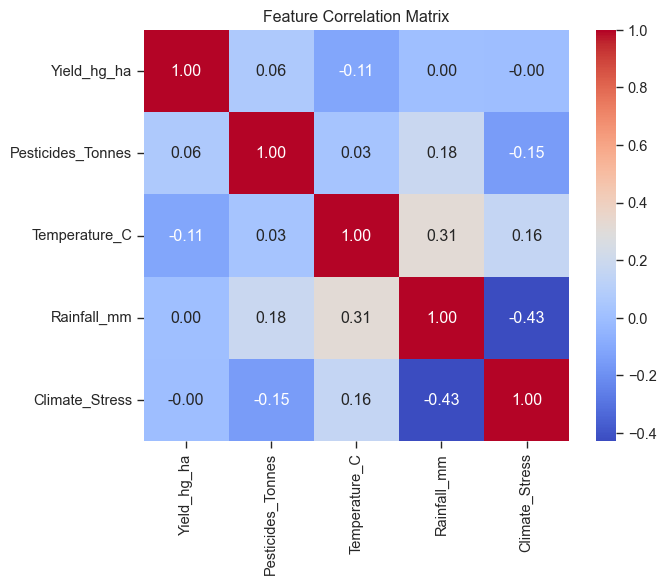

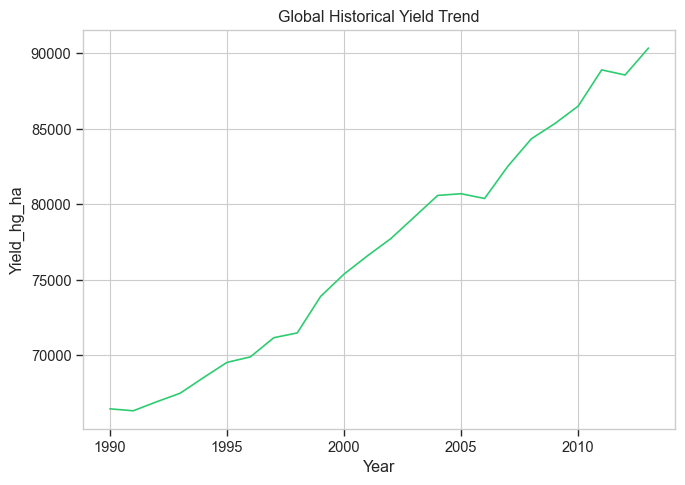

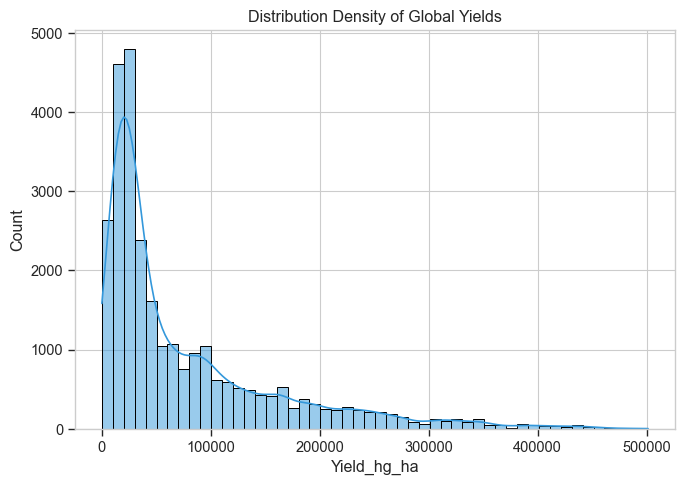

In [7]:
print("Generating Basic Trend Visualizations...")

# --- Fig 1: Correlation ---
plt.figure(figsize=(7, 6))
sns.heatmap(df_engineered[['Yield_hg_ha', 'Pesticides_Tonnes', 'Temperature_C', 'Rainfall_mm', 'Climate_Stress']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
save_and_show("correlation_matrix")

# --- Fig 2: Trend Line ---
plt.figure(figsize=(7, 5))
sns.lineplot(data=df_engineered, x='Year', y='Yield_hg_ha', estimator='mean', errorbar=None, color='#2ecc71')
plt.title('Global Historical Yield Trend')
save_and_show("yield_trend_line")

# --- Fig 3: Density ---
plt.figure(figsize=(7, 5))
sns.histplot(df_engineered['Yield_hg_ha'], bins=50, kde=True, color='#3498db')
plt.title('Distribution Density of Global Yields')
save_and_show("yield_histogram")

Generating Regional & Crop Visualizations...


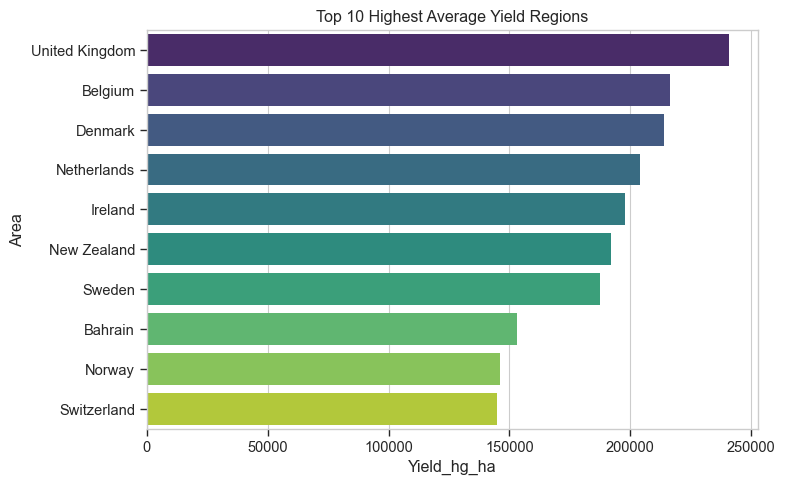

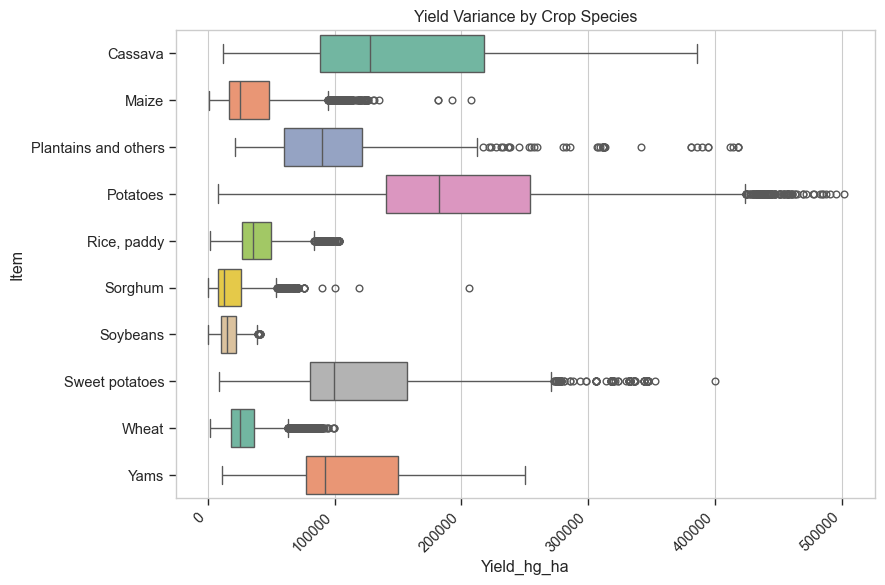

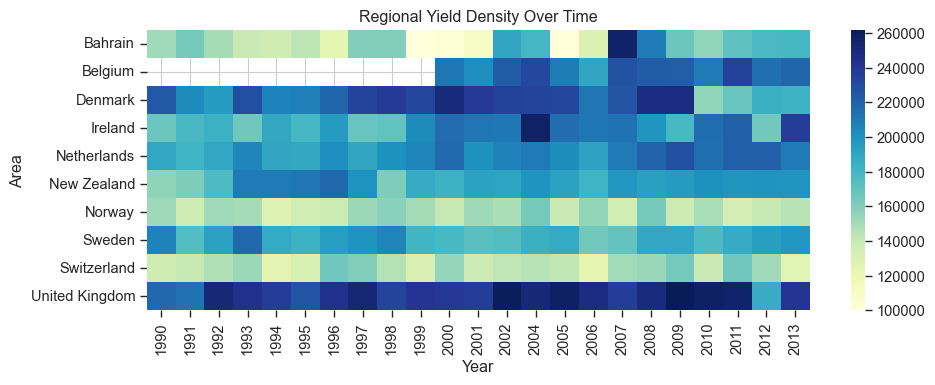

In [8]:
print("Generating Regional & Crop Visualizations...")

# --- Fig 4: Top Yielding Regions ---
top_areas = df_engineered.groupby('Area', observed=True)['Yield_hg_ha'].mean().sort_values(ascending=False).head(10).reset_index()
top_areas['Area'] = top_areas['Area'].astype(str)
plt.figure(figsize=(8, 5))
sns.barplot(data=top_areas, x='Yield_hg_ha', y='Area', palette='viridis')
plt.title('Top 10 Highest Average Yield Regions')
save_and_show("top_countries_bar")

# --- Fig 5: Crop Variance ---
plt.figure(figsize=(9, 6))
sns.boxplot(data=df_engineered, x='Yield_hg_ha', y='Item', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Yield Variance by Crop Species')
save_and_show("crop_variance_boxplot")

# --- Fig 16: Heatmap ---
top_10_areas = top_areas['Area'].tolist()
heatmap_data = df_engineered[df_engineered['Area'].isin(top_10_areas)].pivot_table(index='Area', columns='Year', values='Yield_hg_ha', aggfunc='mean')
plt.figure(figsize=(10, 4))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False)
plt.title('Regional Yield Density Over Time')
plt.yticks(rotation=0)
save_and_show("regional_yield_heatmap")

Generating Advanced Stress Analytics...


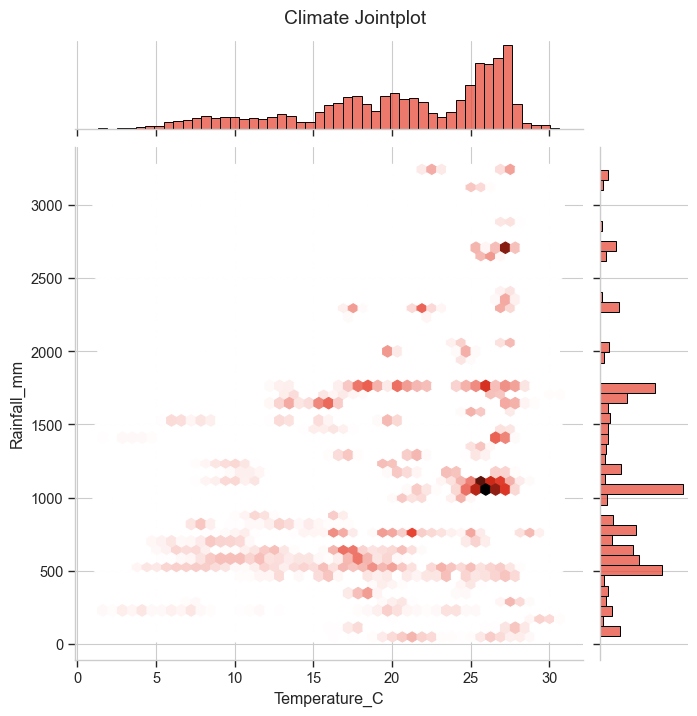

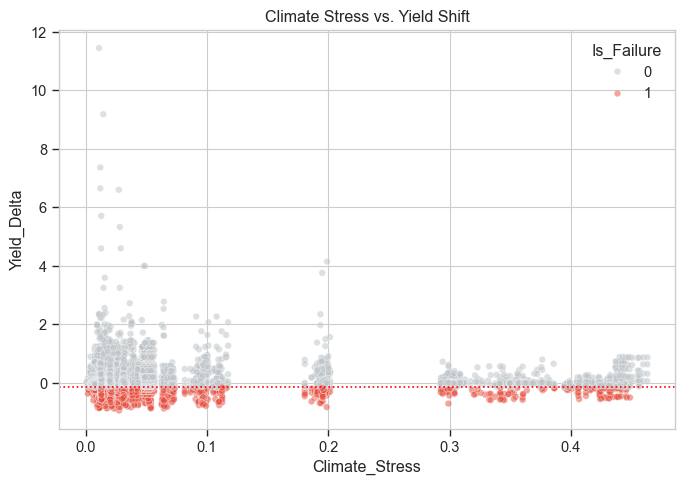

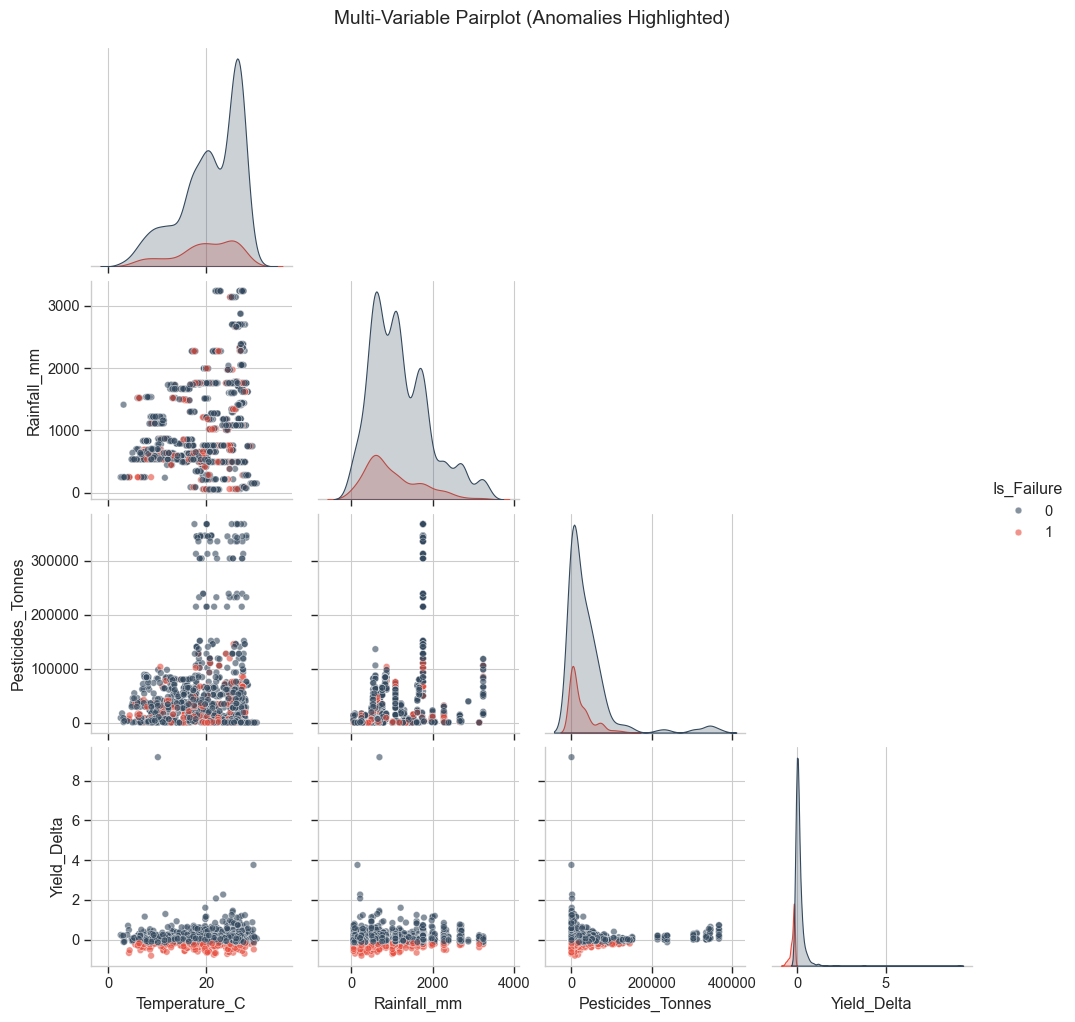

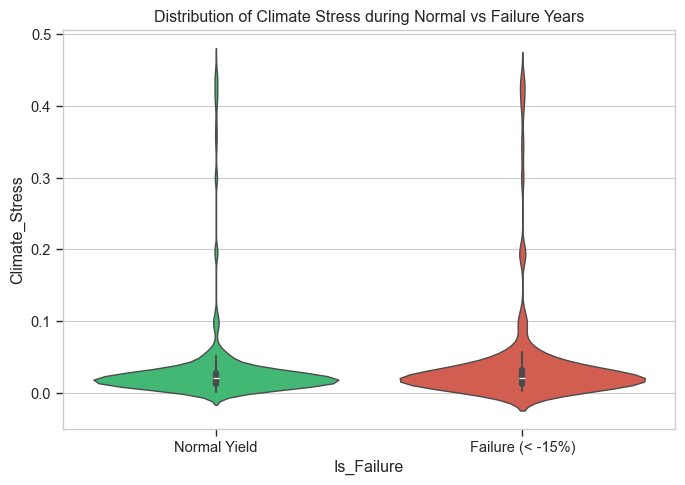

In [9]:
print("Generating Advanced Stress Analytics...")

# --- Fig 6: Jointplot ---
joint_fig = sns.jointplot(data=df_engineered, x='Temperature_C', y='Rainfall_mm', kind='hex', color='#e74c3c', height=7)
joint_fig.fig.suptitle('Climate Jointplot', y=1.02)
joint_fig.savefig(f"{PATHS['figures']}climate_jointplot.svg", format='svg')
joint_fig.savefig(f"{PATHS['figures']}climate_jointplot.pdf", format='pdf')
plt.show()

# --- Fig 15: Stress Impact ---
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_engineered, x='Climate_Stress', y='Yield_Delta', hue='Is_Failure', palette={0: '#bdc3c7', 1: '#e74c3c'}, alpha=0.5)
plt.axhline(-0.15, color='red', linestyle=':', label='Failure Threshold (-15%)')
plt.title('Climate Stress vs. Yield Shift')
save_and_show("climate_stress_impact")

# --- NEW Fig 17: Pairplot (Sampled for speed) ---
sampled_df = df_engineered.sample(n=min(2000, len(df_engineered)), random_state=42)
pair_cols = ['Temperature_C', 'Rainfall_mm', 'Pesticides_Tonnes', 'Yield_Delta', 'Is_Failure']
pair_fig = sns.pairplot(sampled_df[pair_cols], hue='Is_Failure', palette={0: '#34495e', 1: '#e74c3c'}, plot_kws={'alpha':0.6}, corner=True)
pair_fig.fig.suptitle('Multi-Variable Pairplot (Anomalies Highlighted)', y=1.02)
pair_fig.savefig(f"{PATHS['figures']}variable_pairplot.svg", format='svg')
pair_fig.savefig(f"{PATHS['figures']}variable_pairplot.pdf", format='pdf')
plt.show()

# --- NEW Fig 18: Violin Plot ---
plt.figure(figsize=(7, 5))
sns.violinplot(data=df_engineered, x='Is_Failure', y='Climate_Stress', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Climate Stress during Normal vs Failure Years')
plt.xticks([0, 1], ['Normal Yield', 'Failure (< -15%)'])
save_and_show("stress_violin_plot")

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Preparing Data for Regressor...")

# 1. Define Features and Target
features_reg = ['Year', 'Pesticides_Tonnes', 'Temperature_C', 'Rainfall_mm', 'Climate_Stress', 'Area', 'Item']
X_reg = df_engineered[features_reg]
y_reg = df_engineered['Yield_Delta']

# 2. Train/Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Initialize and Train Model
print("Training XGBoost Regressor...")
reg_model = xgb.XGBRegressor(
    enable_categorical=True, n_estimators=250, learning_rate=0.08, max_depth=6, random_state=42, n_jobs=-1
)
reg_model.fit(X_train_r, y_train_r)

# 4. Save Model
joblib.dump(reg_model, f"{PATHS['models']}agri_delta_regressor.pkl")
print(f"✅ Regressor successfully saved to: {PATHS['models']}agri_delta_regressor.pkl\n")

# 5. Predict and Calculate Metrics
y_pred_r = reg_model.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("="*43)
print(f"📊 REGRESSOR PERFORMANCE")
print(f"RMSE: {rmse:.4f}  |  MAE: {mae:.4f}  |  R²: {r2:.4f}")
print("="*43)

# 6. Live Prediction Preview
preview_df = pd.DataFrame({
    'Actual_Delta': y_test_r.values[:5],
    'Predicted_Delta': y_pred_r[:5],
    'Error_Margin': (y_test_r.values[:5] - y_pred_r[:5])
})
print("\n🔍 Live Prediction Preview (First 5 Test Rows):")
display(preview_df.round(4))

Preparing Data for Regressor...
Training XGBoost Regressor...
✅ Regressor successfully saved to: models/agri_delta_regressor.pkl

📊 REGRESSOR PERFORMANCE
RMSE: 0.1770  |  MAE: 0.0895  |  R²: 0.6464

🔍 Live Prediction Preview (First 5 Test Rows):


,Actual_Delta,Predicted_Delta,Error_Margin
0,-0.0725,-0.0309,-0.0416
1,0.0141,-0.0551,0.0692
2,-0.0366,0.0192,-0.0558
3,-0.0339,-0.0332,-0.0007
4,0.3906,0.2828,0.1077


Generating Regressor Diagnostic Charts...


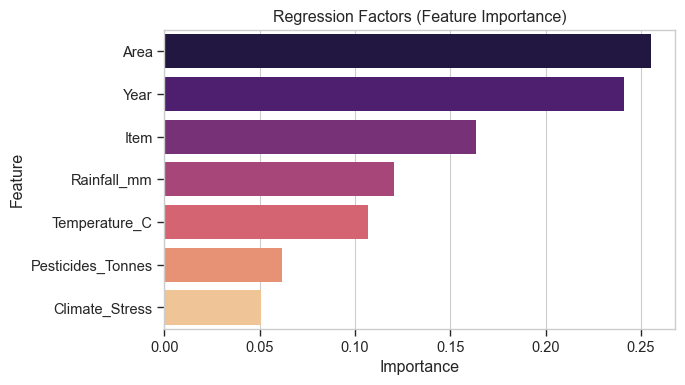

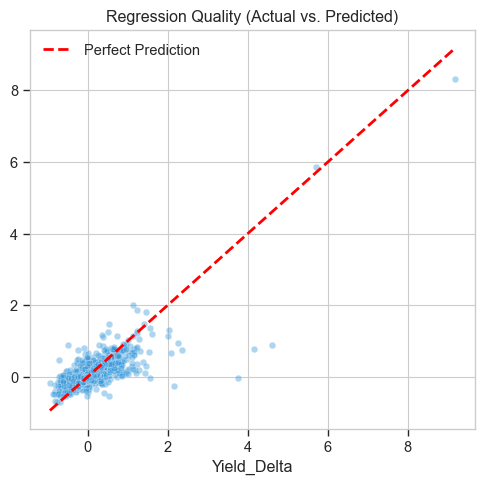

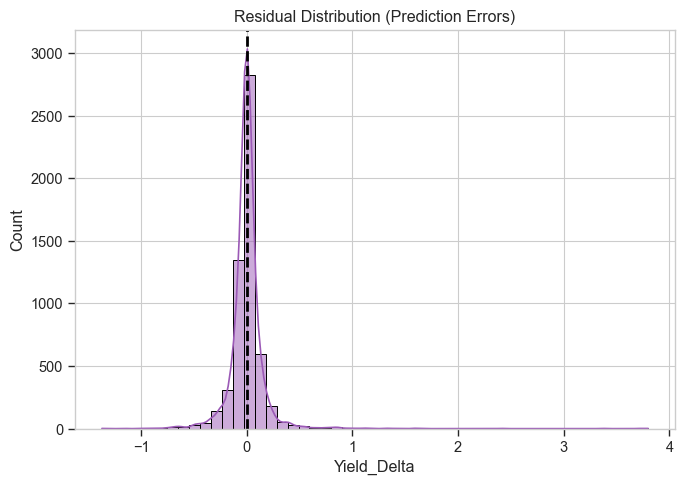

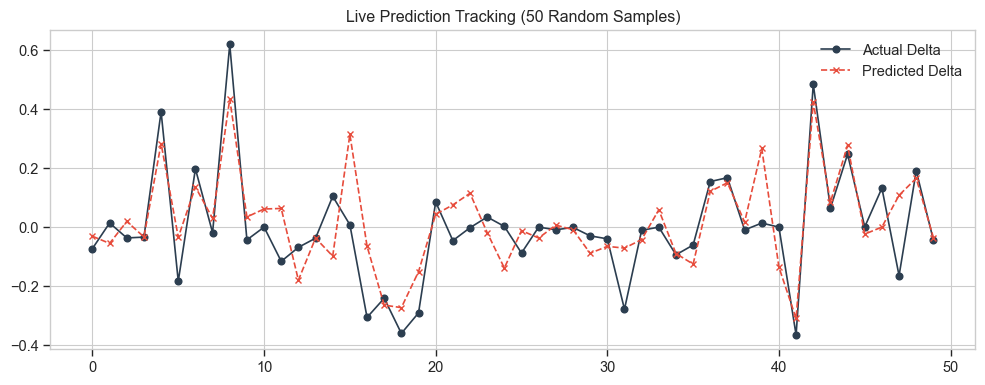

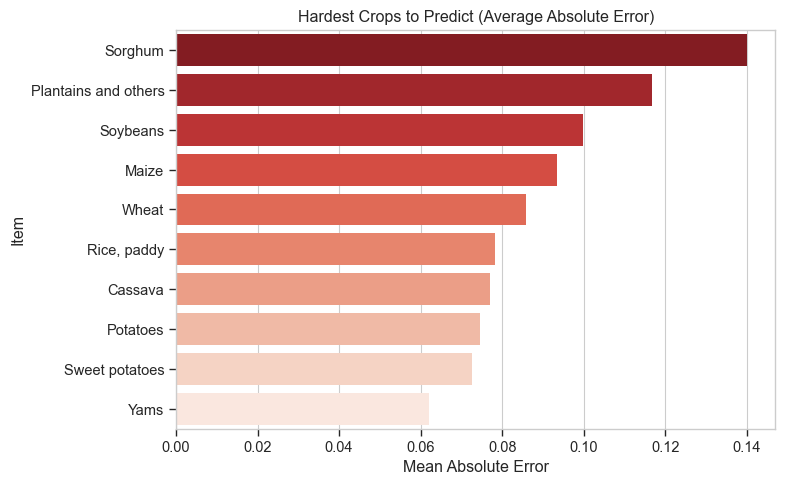

In [11]:
print("Generating Regressor Diagnostic Charts...")

# --- Fig 7: Feature Importance ---
plt.figure(figsize=(7, 4))
feat_imp = pd.DataFrame({'Feature': features_reg, 'Importance': reg_model.feature_importances_}).sort_values(by='Importance', ascending=False)
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='magma')
plt.title('Regression Factors (Feature Importance)')
save_and_show("regressor_importance")

# --- Fig 8: Scatter Quality ---
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.4, color='#3498db')
min_val, max_val = min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.title('Regression Quality (Actual vs. Predicted)')
plt.legend()
save_and_show("prediction_scatter")

# --- Fig 12: Residual Distribution ---
plt.figure(figsize=(7, 5))
residuals = y_test_r - y_pred_r
sns.histplot(residuals, bins=50, kde=True, color='#9b59b6')
plt.axvline(0, color='black', linestyle='--', linewidth=2)
plt.title('Residual Distribution (Prediction Errors)')
save_and_show("residual_distribution")

# --- NEW Fig 13: Prediction Tracking Line (Sample of 50) ---
plt.figure(figsize=(10, 4))
plt.plot(y_test_r.values[:50], label='Actual Delta', marker='o', linestyle='-', color='#2c3e50')
plt.plot(y_pred_r[:50], label='Predicted Delta', marker='x', linestyle='--', color='#e74c3c')
plt.title('Live Prediction Tracking (50 Random Samples)')
plt.legend()
save_and_show("prediction_tracking_line")

# --- NEW Fig 14: Error by Crop Type ---
# Calculate absolute error per item
error_df = pd.DataFrame({'Item': X_test_r['Item'], 'Abs_Error': np.abs(residuals)})
avg_error_crop = error_df.groupby('Item', observed=True)['Abs_Error'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_error_crop.values, y=avg_error_crop.index.astype(str), palette='Reds_r')
plt.title('Hardest Crops to Predict (Average Absolute Error)')
plt.xlabel('Mean Absolute Error')
save_and_show("error_by_crop")

In [12]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, roc_curve

print("Preparing Data for Classifier...")

# 1. Define Features (Intentional drop of Climate_Stress)
features_clf = ['Year', 'Pesticides_Tonnes', 'Temperature_C', 'Rainfall_mm', 'Area', 'Item']
X_clf = df_engineered[features_clf]
y_clf = df_engineered['Is_Failure']

# 2. Train/Test Split (Stratified)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# 3. Train Model
print("Training XGBoost Classifier...")
clf_model = xgb.XGBClassifier(
    enable_categorical=True, n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss', n_jobs=-1
)
clf_model.fit(X_train_c, y_train_c)

# 4. Save Model
joblib.dump(clf_model, f"{PATHS['models']}agri_failure_classifier.pkl")
print(f"✅ Classifier successfully saved to: {PATHS['models']}agri_failure_classifier.pkl\n")

# 5. Predict
y_pred_c = clf_model.predict(X_test_c)
y_prob_c = clf_model.predict_proba(X_test_c)[:, 1]

# 6. Detailed Metrics
print("="*53)
print(f"📊 CLASSIFIER PERFORMANCE REPORT")
print("="*53)
print(classification_report(y_test_c, y_pred_c, target_names=['Normal (0)', 'Failure (1)']))

cm = confusion_matrix(y_test_c, y_pred_c)
print(f"\nRAW MATRIX NUMBERS:")
print(f"True Negatives: {cm[0][0]}  |  False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}  |  True Positives: {cm[1][1]}")
print(f"ROC-AUC Score: {roc_auc_score(y_test_c, y_prob_c):.4f}")

Preparing Data for Classifier...
Training XGBoost Classifier...
✅ Classifier successfully saved to: models/agri_failure_classifier.pkl

📊 CLASSIFIER PERFORMANCE REPORT
              precision    recall  f1-score   support

  Normal (0)       0.93      0.98      0.95      4747
 Failure (1)       0.83      0.62      0.71       902

    accuracy                           0.92      5649
   macro avg       0.88      0.80      0.83      5649
weighted avg       0.91      0.92      0.91      5649


RAW MATRIX NUMBERS:
True Negatives: 4634  |  False Positives: 113
False Negatives: 346  |  True Positives: 556
ROC-AUC Score: 0.9476


Generating Classifier Diagnostic Charts...


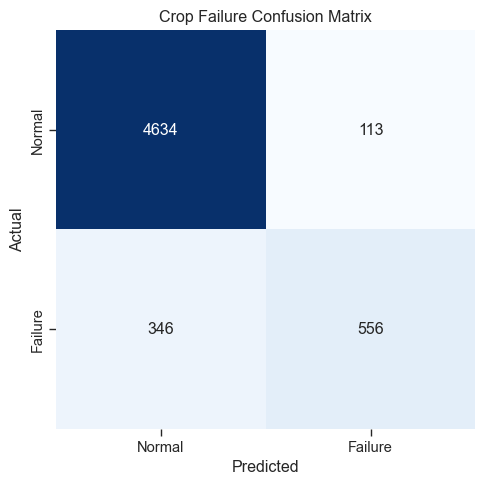

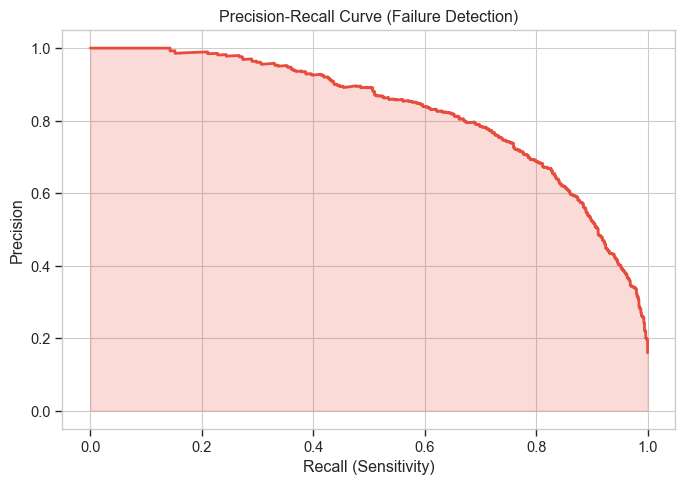

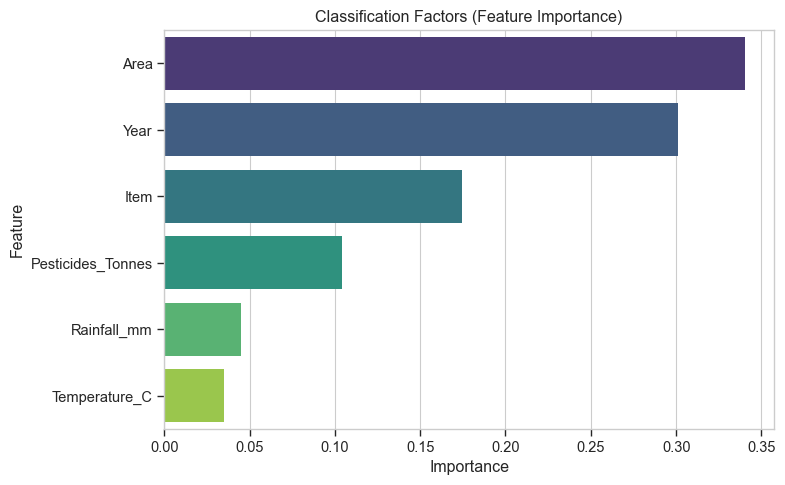

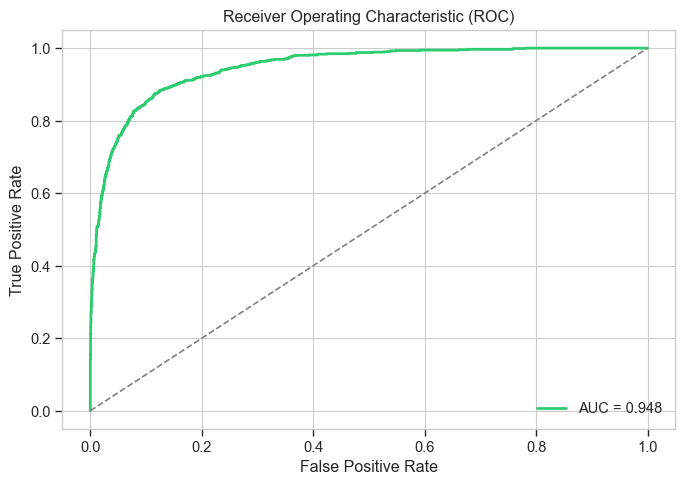

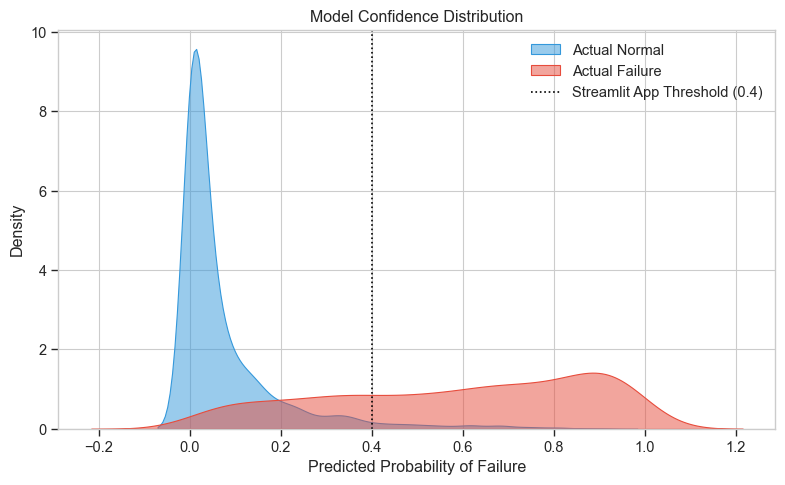

In [13]:
print("Generating Classifier Diagnostic Charts...")

# --- Fig 9: Confusion Matrix (REQUIRED BY APP) ---
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'])
plt.title('Crop Failure Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
save_and_show("failure_confusion_matrix")

# --- Fig 10: Precision-Recall Curve (REQUIRED BY APP) ---
plt.figure(figsize=(7, 5))
precision, recall, _ = precision_recall_curve(y_test_c, y_prob_c)
plt.plot(recall, precision, color='#e74c3c', lw=2)
plt.fill_between(recall, precision, alpha=0.2, color='#e74c3c')
plt.title('Precision-Recall Curve (Failure Detection)')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision')
save_and_show("precision_recall_curve")

# --- Fig 11: Feature Importance (REQUIRED BY APP) ---
plt.figure(figsize=(8, 5))
feat_imp_clf = pd.DataFrame({'Feature': features_clf, 'Importance': clf_model.feature_importances_}).sort_values(by='Importance', ascending=False)
sns.barplot(data=feat_imp_clf, x='Importance', y='Feature', palette='viridis')
plt.title('Classification Factors (Feature Importance)')
save_and_show("classifier_importance")

# --- Fig 21: ROC Curve (Renumbered from 20) ---
plt.figure(figsize=(7, 5))
fpr, tpr, _ = roc_curve(y_test_c, y_prob_c)
plt.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'AUC = {roc_auc_score(y_test_c, y_prob_c):.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
save_and_show("roc_curve")

# --- Fig 22: Confidence Distribution (Renumbered from 21) ---
plt.figure(figsize=(8, 5))
sns.kdeplot(y_prob_c[y_test_c == 0], label='Actual Normal', color='#3498db', fill=True, alpha=0.5)
sns.kdeplot(y_prob_c[y_test_c == 1], label='Actual Failure', color='#e74c3c', fill=True, alpha=0.5)
plt.axvline(0.4, color='black', linestyle=':', label='Streamlit App Threshold (0.4)')
plt.title('Model Confidence Distribution')
plt.xlabel('Predicted Probability of Failure')
plt.legend()
save_and_show("confidence_distribution")

Generating Final Temporal Analytics...


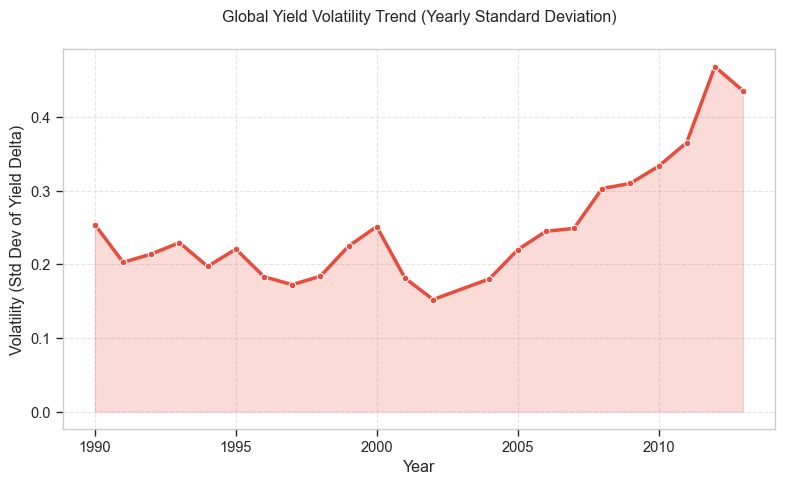

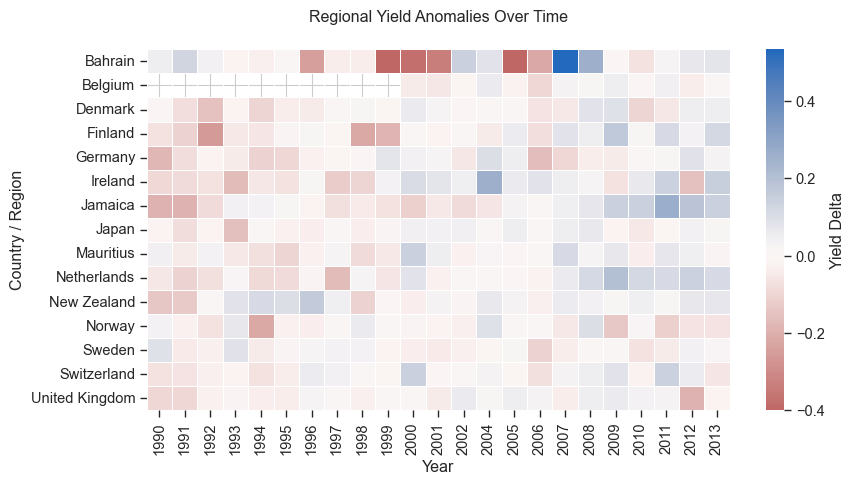

🎉 Master Pipeline 100% Complete! All 22 Visualizations and models are beautifully generated and saved.


In [14]:
print("Generating Final Temporal Analytics...")

# --- Fig 19: Global Yield Volatility Trend ---
plt.figure(figsize=(8, 5))
# Calculate the yearly standard deviation of Yield Delta (Volatility)
yearly_volatility = df_engineered.groupby('Year')['Yield_Delta'].std().reset_index()

sns.lineplot(data=yearly_volatility, x='Year', y='Yield_Delta', color='#e74c3c', linewidth=2.5, marker='o')
plt.fill_between(yearly_volatility['Year'], yearly_volatility['Yield_Delta'], alpha=0.2, color='#e74c3c')

plt.title('Global Yield Volatility Trend (Yearly Standard Deviation)', pad=20)
plt.xlabel('Year')
plt.ylabel('Volatility (Std Dev of Yield Delta)')
plt.grid(True, linestyle='--', alpha=0.5)
save_and_show("temporal_volatility_trend")

# --- Fig 20: Regional Yield Anomalies Over Time ---
plt.figure(figsize=(9, 5))
# Pivot to see average Yield Delta by Year and Area (Using top 15 Areas)
top_areas_list = df_engineered.groupby('Area', observed=True)['Yield_hg_ha'].mean().sort_values(ascending=False).head(15).index

anomaly_data = df_engineered[df_engineered['Area'].isin(top_areas_list)].pivot_table(
    index='Area', columns='Year', values='Yield_Delta', aggfunc='mean'
)

# Center the colormap at 0 (white), negative is red, positive is blue
sns.heatmap(anomaly_data, cmap='vlag_r', center=0, annot=False, linewidths=0.5, cbar_kws={'label': 'Yield Delta'})

plt.title('Regional Yield Anomalies Over Time', pad=20)
plt.xlabel('Year')
plt.ylabel('Country / Region')
plt.yticks(rotation=0)
save_and_show("regional_anomaly_heatmap")

print("🎉 Master Pipeline 100% Complete! All 22 Visualizations and models are beautifully generated and saved.")